In [1]:
import pandas as pd 
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv("diabetes_prediction_dataset.csv")
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
data['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
data.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

<Axes: >

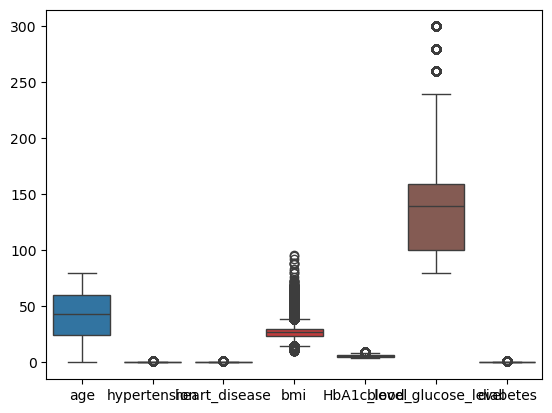

In [8]:
sns.boxplot(data)

In [9]:
data = data[(data['bmi'] >= 10) & (data['bmi'] <= 80)]

In [10]:
print("BMI range:", data['bmi'].min(), "-", data['bmi'].max())

BMI range: 10.01 - 79.48


In [11]:
x = data.iloc[:,:-1]
y = data["diabetes"]

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
label_encoders = {}
cat_cols = ["gender", "smoking_history"]
for col in cat_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoders[col] = le


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,train_size=0.2)

In [16]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression(random_state=42)
model1.fit(x_train, y_train)



LogisticRegression(random_state=42)

In [17]:
y_pred=model1.predict(x_test)

In [18]:
from sklearn.metrics import accuracy_score

# Correct usage if you want to compare predictions vs true labels manually
print(accuracy_score(y_test, y_pred))

0.9591089220306777


In [19]:
from sklearn.linear_model import LogisticRegressionCV
model = LogisticRegressionCV(cv=5,random_state=42)
model.fit_intercept=True   # set bias and fit prefect data
model.fit(x_train, y_train)


LogisticRegressionCV(cv=5, random_state=42)

In [20]:
print(f"Best Regularization Strength (C): {model.C_}")
print(model.score(x_test, y_test))

Best Regularization Strength (C): [2.7825594]
0.9599339942244947


In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
R_c = RandomForestClassifier()
R_c.fit(x_train,y_train)

RandomForestClassifier()

In [23]:
y_predction = R_c.predict(x_test)

In [24]:
from sklearn.metrics import accuracy_score
# Correct usage if you want to compare predictions vs true labels manually
print(accuracy_score(y_test, y_predction))

0.9708349480579551


In [25]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegressionCV

# Pehle se bane huye models ko list mein daalein
#  Yahan brackets () nahi lagane kyunki models already trained/defined hain
estimators = [
    ('lr_cv', model), 
    ('rf', R_c)
]

# 2. Stacking Classifier banayein
# Hum final_estimator mein ek simple Logistic Regression rakhte hain
stack_model = StackingClassifier(
    estimators=estimators, 
    final_estimator=LogisticRegressionCV(max_iter=1000)
)

# 3. Train karein
stack_model.fit(x_train, y_train)

# 4. Score check karein
print(f"Stacking Accuracy: {stack_model.score(x_test, y_test)}")

Stacking Accuracy: 0.9713474929056293


In [26]:
print(f"LogisticCV Accuracy: {model.score(x_test, y_test)}")
print(f"RandomForest Accuracy: {R_c.score(x_test, y_test)}")
print(f"Stacking Accuracy: {stack_model.score(x_test, y_test)}")

LogisticCV Accuracy: 0.9599339942244947
RandomForest Accuracy: 0.9708349480579551
Stacking Accuracy: 0.9713474929056293


In [ ]:
from sklearn.ensemble import VotingClassifier

# 'soft' voting use karne ke liye zaroori hai ki models probability nikal sakein
v_model = VotingClassifier(
    estimators=[('lr', model), ('rf', R_c)],
    voting='soft'
)

v_model.fit(x_train, y_train)
print(f"Voting Accuracy: {v_model.score(x_test, y_test)}")

In [ ]:
train_acc = stack_model.score(x_train, y_train)
test_acc = stack_model.score(x_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.model_selection import learning_curve

# train_sizes, train_scores, test_scores = learning_curve(
#     stack_model,
#     x,
#     y,
#     cv=5,
#     scoring='accuracy',
#     train_sizes=np.linspace(0.1, 1.0, 10)
# )

# train_mean = train_scores.mean(axis=1)
# test_mean = test_scores.mean(axis=1)

# plt.figure()
# plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
# plt.plot(train_sizes, test_mean, marker='o', label='Validation Accuracy')
# plt.xlabel("Training Data Size")
# plt.ylabel("Accuracy")
# plt.title("Learning Curve – Diabetes Prediction Model")
# plt.legend()
# plt.show()


In [ ]:
new_patient = pd.DataFrame([{
    'gender': 'Female',
    'age': 61,
    'hypertension': 0,
    'heart_disease': 0,
    'smoking_history': 'current',
    'bmi': 30.11,
    'HbA1c_level':6.2,
    'blood_glucose_level': 240
}])
for col in cat_cols:
    new_patient[col] = label_encoders[col].transform(new_patient[col])



In [ ]:
prediction = stack_model.predict(new_patient)
probability = stack_model.predict_proba(new_patient)

print("Prediction (0 = No Diabetes, 1 = Diabetes):", prediction[0])
print("Diabetes Probability:", probability[0][1])
